# 2B-Class QLoRA Fine-Tuning for PropBank SRL Question Answering

**Project title:** Generative semantic role question answering with a 2B-class instruction-tuned foundation model

**Problem statement:** Given a PropBank sentence, predicate, and semantic role label, train a 2B-class language model to answer an SRL question by generating the correct argument span from the sentence.

This notebook is a research-style, end-to-end project. It loads NLTK PropBank, converts predicate-argument annotations into question-answer examples, performs detailed EDA, selects a Colab-free-tier-compatible 2B-class pretrained model, fine-tunes with LoRA/QLoRA, evaluates exact answer generation, and produces a paper-style analysis.

**Full Colab model:** `google/gemma-2-2b-it` with QLoRA. The Hugging Face model card describes Gemma as a decoder-only text-to-text model family and shows 4-bit bitsandbytes loading examples. The Gemma files require accepting Google's Gemma license on Hugging Face before first use.

**Local execution note:** This notebook defaults to `FAST_DEV_RUN=True`, which uses `sshleifer/tiny-gpt2` so every cell can run on CPU. Set `FAST_DEV_RUN=False` in Colab GPU after accepting the Gemma license to run the 2B-class QLoRA experiment.

**Accuracy target:** The notebook tracks an 80 percent target as a research goal. It does not fake this result; if the run misses the target, it reports that honestly and suggests experimental improvements.

## 1. Install and Import Dependencies

Colab installs PEFT and bitsandbytes automatically. Local execution skips package installation and uses the existing environment.

In [1]:
import os
import sys
import subprocess
import importlib.util

IN_COLAB = 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))

if IN_COLAB:
    packages = [
        'nltk>=3.8.1',
        'transformers>=4.45.0',
        'accelerate>=0.30.0',
        'peft>=0.11.0',
        'bitsandbytes>=0.43.1',
        'sentencepiece>=0.2.0',
        'scikit-learn>=1.3.0',
        'seaborn>=0.13.0',
        'matplotlib>=3.8.0',
        'pandas>=2.0.0',
    ]
    print('Colab detected. Installing dependencies for Gemma QLoRA...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
else:
    print('Local runtime detected. Skipping automatic pip install.')

for module_name in ['nltk', 'torch', 'transformers', 'peft', 'bitsandbytes', 'pandas', 'sklearn', 'seaborn']:
    print(f'{module_name:>12}:', importlib.util.find_spec(module_name) is not None)
print('IN_COLAB =', IN_COLAB)

Local runtime detected. Skipping automatic pip install.
        nltk: True
       torch: True
transformers: True
        peft: True
bitsandbytes: False
      pandas: True
     sklearn: True
     seaborn: True
IN_COLAB = False


## 2. Reproducibility and Experiment Configuration

For final 2B training, run on a Colab GPU and set `FAST_DEV_RUN=False`. If Gemma access is gated in your Hugging Face account, run `from huggingface_hub import notebook_login; notebook_login()` before loading the model.

In [2]:
import gc
import json
import math
import random
import re
import shutil
import time
import warnings
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import propbank
from nltk.tree import Tree

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from transformers import AutoModelForCausalLM, AutoTokenizer, get_linear_schedule_with_warmup

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Torch:', torch.__version__)

PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'propbank_srlqa_2b_artifacts'
PLOT_DIR = ARTIFACT_DIR / 'plots'
CHECKPOINT_DIR = ARTIFACT_DIR / 'best_generative_checkpoint'
for directory in [ARTIFACT_DIR, PLOT_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FAST_DEV_RUN = os.environ.get('FAST_DEV_RUN', '1') == '1'
FULL_2B_MODEL_NAME = 'google/gemma-2-2b-it'
SMOKE_TEST_MODEL_NAME = 'sshleifer/tiny-gpt2'
MODEL_NAME = SMOKE_TEST_MODEL_NAME if FAST_DEV_RUN else FULL_2B_MODEL_NAME
REQUESTED_TUNING_METHOD = 'lora' if FAST_DEV_RUN else 'qlora'

MAX_INSTANCES_FOR_CONVERSION = 1300 if FAST_DEV_RUN else None
MAX_QA_EXAMPLES = 80 if FAST_DEV_RUN else 6000
MAX_LENGTH = 192 if FAST_DEV_RUN else 512
MAX_PROMPT_LENGTH = 160 if FAST_DEV_RUN else 416
MAX_NEW_TOKENS = 18 if FAST_DEV_RUN else 48
BATCH_SIZE = 4 if FAST_DEV_RUN else 1
GRADIENT_ACCUMULATION_STEPS = 1 if FAST_DEV_RUN else 8
NUM_EPOCHS = 1 if FAST_DEV_RUN else 3
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05
EARLY_STOPPING_PATIENCE = 1 if FAST_DEV_RUN else 2
TARGET_EXACT_MATCH = 0.80
TARGET_TOKEN_F1 = 0.80

print(json.dumps({
    'FAST_DEV_RUN': FAST_DEV_RUN,
    'MODEL_NAME': MODEL_NAME,
    'REQUESTED_TUNING_METHOD': REQUESTED_TUNING_METHOD,
    'MAX_QA_EXAMPLES': MAX_QA_EXAMPLES,
    'MAX_LENGTH': MAX_LENGTH,
    'MAX_PROMPT_LENGTH': MAX_PROMPT_LENGTH,
    'BATCH_SIZE': BATCH_SIZE,
    'GRADIENT_ACCUMULATION_STEPS': GRADIENT_ACCUMULATION_STEPS,
    'NUM_EPOCHS': NUM_EPOCHS,
    'TARGET_EXACT_MATCH': TARGET_EXACT_MATCH,
    'TARGET_TOKEN_F1': TARGET_TOKEN_F1,
}, indent=2))

Device: cpu
Torch: 2.10.0+cpu
{
  "FAST_DEV_RUN": true,
  "MODEL_NAME": "sshleifer/tiny-gpt2",
  "REQUESTED_TUNING_METHOD": "lora",
  "MAX_QA_EXAMPLES": 80,
  "MAX_LENGTH": 192,
  "MAX_PROMPT_LENGTH": 160,
  "BATCH_SIZE": 4,
  "GRADIENT_ACCUMULATION_STEPS": 1,
  "NUM_EPOCHS": 1,
  "TARGET_EXACT_MATCH": 0.8,
  "TARGET_TOKEN_F1": 0.8
}


## 3. Load and Inspect NLTK PropBank

PropBank represents semantic roles as predicate-argument annotations over Penn Treebank parse trees. Each instance has a roleset such as `join.01`, a predicate pointer, argument pointers, and the sentence tree. We convert each argument into one question-answer training example.

In [3]:
for package_name in ['propbank', 'treebank']:
    nltk.download(package_name, quiet=True)

instances = propbank.instances()
print(f'Loaded PropBank instances: {len(instances):,}')

sample = instances[0]
print('Raw sample:')
print(sample)
print('Roleset:', sample.roleset)
print('Predicate pointer:', sample.predicate)
print('Arguments:', sample.arguments[:5])
print('Sentence leaves:', sample.tree.leaves())
print('Parse tree:')
print(sample.tree)

roleset_xml = propbank.roleset(sample.roleset)
print('Roleset metadata:', roleset_xml.attrib)
for role in roleset_xml.findall('.//role'):
    print(f"ARG{role.attrib.get('n')}: {role.attrib.get('descr')}")

Loaded PropBank instances: 112,917
Raw sample:
wsj_0001.mrg 0 8 gold join.01 vf--a 0:2-ARG0 7:0-ARGM-MOD 8:0-rel 9:1-ARG1 11:1-ARGM-PRD 15:1-ARGM-TMP
Roleset: join.01
Predicate pointer: 8:0
Arguments: ((PropbankTreePointer(0, 2), 'ARG0'), (PropbankTreePointer(7, 0), 'ARGM-MOD'), (PropbankTreePointer(9, 1), 'ARG1'), (PropbankTreePointer(11, 1), 'ARGM-PRD'), (PropbankTreePointer(15, 1), 'ARGM-TMP'))
Sentence leaves: ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
Parse tree:
(S
  (NP-SBJ
    (NP (NNP Pierre) (NNP Vinken))
    (, ,)
    (ADJP (NP (CD 61) (NNS years)) (JJ old))
    (, ,))
  (VP
    (MD will)
    (VP
      (VB join)
      (NP (DT the) (NN board))
      (PP-CLR (IN as) (NP (DT a) (JJ nonexecutive) (NN director)))
      (NP-TMP (NNP Nov.) (CD 29))))
  (. .))
Roleset metadata: {'id': 'join.01', 'name': 'attach', 'vncls': '22.1-2'}
ARG0: agent, entity doing the tying
ARG1: patient, th

## 4. Convert PropBank to Generative SRL-QA Examples

We use a generative formulation:

- **Prompt:** sentence, predicate, roleset, semantic role label, and a natural-language role question.
- **Target:** exact PropBank argument span.

This formulation matches decoder-only 2B-class models such as Gemma. It can handle natural-language prompting, but the single-string target still inherits an extractive limitation: discontinuous PropBank arguments are filtered unless their non-trace leaves become a contiguous surface span.

In [4]:
ARGM_DESCRIPTIONS = {
    'ARGM-ADV': 'adverbial or general-purpose modifier',
    'ARGM-CAU': 'cause or reason',
    'ARGM-COM': 'comitative or companion',
    'ARGM-DIR': 'direction',
    'ARGM-DIS': 'discourse connective',
    'ARGM-EXT': 'extent',
    'ARGM-LOC': 'location',
    'ARGM-MNR': 'manner',
    'ARGM-MOD': 'modal auxiliary',
    'ARGM-NEG': 'negation marker',
    'ARGM-PNC': 'purpose',
    'ARGM-PRD': 'secondary predication',
    'ARGM-REC': 'reciprocal',
    'ARGM-TMP': 'temporal modifier',
}

QUESTION_TEMPLATES = {
    'ARGM-TMP': 'When does the predicate {roleset} ({sense}) happen?',
    'ARGM-LOC': 'Where does the predicate {roleset} ({sense}) happen?',
    'ARGM-MNR': 'How does the predicate {roleset} ({sense}) happen?',
    'ARGM-CAU': 'Why does the predicate {roleset} ({sense}) happen?',
    'ARGM-PNC': 'For what purpose does the predicate {roleset} ({sense}) happen?',
    'ARGM-MOD': 'What modal expression modifies the predicate {roleset} ({sense})?',
    'ARGM-NEG': 'What negation modifies the predicate {roleset} ({sense})?',
}


def clean_tokens_and_mapping(tree: Tree) -> Tuple[List[str], Dict[int, int], List[Tuple[int, ...]]]:
    positions = list(tree.treepositions('leaves'))
    clean_tokens = []
    raw_to_clean = {}
    for raw_index, position in enumerate(positions):
        token = tree[position]
        parent_position = position[:-1]
        parent_label = tree[parent_position].label() if parent_position and isinstance(tree[parent_position], Tree) else ''
        if parent_label == '-NONE-':
            continue
        raw_to_clean[raw_index] = len(clean_tokens)
        clean_tokens.append(token)
    return clean_tokens, raw_to_clean, positions


def join_tokens_with_offsets(tokens: Sequence[str]) -> Tuple[str, List[Tuple[int, int]]]:
    text_parts, offsets, cursor = [], [], 0
    for token in tokens:
        if text_parts:
            text_parts.append(' ')
            cursor += 1
        start = cursor
        text_parts.append(token)
        cursor += len(token)
        offsets.append((start, cursor))
    return ''.join(text_parts), offsets


def pointer_raw_leaf_indices(pointer, tree: Tree, positions: List[Tuple[int, ...]]) -> List[int]:
    if hasattr(pointer, 'pieces'):
        collected = []
        for piece in pointer.pieces:
            collected.extend(pointer_raw_leaf_indices(piece, tree, positions))
        return sorted(set(collected))
    tree_position = pointer.treepos(tree)
    prefix_length = len(tree_position)
    return [index for index, position in enumerate(positions) if position[:prefix_length] == tree_position]


def role_description(roleset_id: str, label: str) -> str:
    numbered_match = re.fullmatch(r'ARG(\d+)', label)
    if numbered_match:
        try:
            for role in propbank.roleset(roleset_id).findall('.//role'):
                if role.attrib.get('n') == numbered_match.group(1):
                    return role.attrib.get('descr', f'core semantic role {label}')
        except Exception:
            pass
    return ARGM_DESCRIPTIONS.get(label, f'semantic modifier {label}')


def roleset_sense_name(roleset_id: str) -> str:
    try:
        return propbank.roleset(roleset_id).attrib.get('name', 'predicate sense')
    except Exception:
        return 'predicate sense'


def make_question(roleset_id: str, label: str) -> str:
    sense = roleset_sense_name(roleset_id)
    if label in QUESTION_TEMPLATES:
        return QUESTION_TEMPLATES[label].format(roleset=roleset_id, sense=sense)
    return f'For predicate {roleset_id} meaning {sense}, what is {label}: {role_description(roleset_id, label)}?'


def is_contiguous(indices: Sequence[int]) -> bool:
    if not indices:
        return False
    sorted_indices = sorted(set(indices))
    return sorted_indices == list(range(sorted_indices[0], sorted_indices[-1] + 1))


def build_instruction(record: Dict) -> str:
    return (
        'You are an expert semantic role labeler. Answer with exactly one span copied from the sentence.\n'
        f"Sentence: {record['context']}\n"
        f"Predicate: {record['predicate_surface']}\n"
        f"Roleset: {record['roleset']} ({record['sense']})\n"
        f"Role label: {record['label']}\n"
        f"Role meaning: {record['role_description']}\n"
        f"Question: {record['question']}\n"
        'Answer:'
    )

In [5]:
def propbank_to_srlqa_dataframe(instances, max_instances=None, max_examples=None) -> Tuple[pd.DataFrame, Dict[str, int]]:
    rows = []
    stats = Counter()
    selected_instances = instances if max_instances is None else instances[:max_instances]

    for instance in selected_instances:
        stats['instances_seen'] += 1
        tree = getattr(instance, 'tree', None)
        if tree is None:
            stats['skipped_missing_tree'] += 1
            continue

        try:
            clean_tokens, raw_to_clean, positions = clean_tokens_and_mapping(tree)
            context, token_offsets = join_tokens_with_offsets(clean_tokens)
            predicate_raw = pointer_raw_leaf_indices(instance.predicate, tree, positions)
            predicate_clean = [raw_to_clean[index] for index in predicate_raw if index in raw_to_clean]
            predicate_surface = ' '.join(clean_tokens[index] for index in predicate_clean) if predicate_clean else instance.roleset.split('.')[0]
            sense = roleset_sense_name(instance.roleset)
        except Exception:
            stats['skipped_instance_pointer_error'] += 1
            continue

        for pointer, label in instance.arguments:
            stats['arguments_seen'] += 1
            try:
                raw_indices = pointer_raw_leaf_indices(pointer, tree, positions)
                clean_indices = sorted({raw_to_clean[index] for index in raw_indices if index in raw_to_clean})
            except Exception:
                stats['skipped_argument_pointer_error'] += 1
                continue

            if not clean_indices:
                stats['skipped_trace_only_argument'] += 1
                continue
            if not is_contiguous(clean_indices):
                stats['skipped_discontinuous_argument'] += 1
                continue

            answer_start = token_offsets[clean_indices[0]][0]
            answer_end = token_offsets[clean_indices[-1]][1]
            answer_text = context[answer_start:answer_end]
            if not answer_text.strip():
                stats['skipped_empty_answer'] += 1
                continue

            row = {
                'id': f'{instance.fileid}:{instance.sentnum}:{instance.wordnum}:{label}:{len(rows)}',
                'fileid': instance.fileid,
                'sentnum': instance.sentnum,
                'roleset': instance.roleset,
                'sense': sense,
                'predicate_surface': predicate_surface,
                'label': label,
                'role_description': role_description(instance.roleset, label),
                'question': make_question(instance.roleset, label),
                'context': context,
                'answer_text': answer_text,
                'answer_start': answer_start,
                'answer_end': answer_end,
                'context_token_count': len(clean_tokens),
                'answer_token_count': len(clean_indices),
                'pointer_type': type(pointer).__name__,
            }
            row['instruction'] = build_instruction(row)
            rows.append(row)
            stats['qa_examples_created'] += 1

            if max_examples is not None and len(rows) >= max_examples:
                return pd.DataFrame(rows), dict(stats)

    return pd.DataFrame(rows), dict(stats)


qa_df, conversion_stats = propbank_to_srlqa_dataframe(
    instances,
    max_instances=MAX_INSTANCES_FOR_CONVERSION,
    max_examples=MAX_QA_EXAMPLES,
)

print('Conversion statistics:')
print(json.dumps(conversion_stats, indent=2))
print('QA dataframe shape:', qa_df.shape)
display(qa_df.head(6)[['roleset', 'predicate_surface', 'label', 'question', 'answer_text', 'context']])
print('Example prompt:')
print(qa_df.iloc[0]['instruction'])
print('Gold answer:', qa_df.iloc[0]['answer_text'])

Conversion statistics:
{
  "instances_seen": 37,
  "arguments_seen": 83,
  "qa_examples_created": 80,
  "skipped_trace_only_argument": 2,
  "skipped_discontinuous_argument": 1
}
QA dataframe shape: (80, 17)


,roleset,predicate_surface,label,question,answer_text,context
0,join.01,join,ARG0,"For predicate join.01 meaning attach, what is ...","Pierre Vinken , 61 years old ,","Pierre Vinken , 61 years old , will join the b..."
1,join.01,join,ARGM-MOD,What modal expression modifies the predicate j...,will,"Pierre Vinken , 61 years old , will join the b..."
2,join.01,join,ARG1,"For predicate join.01 meaning attach, what is ...",the board,"Pierre Vinken , 61 years old , will join the b..."
3,join.01,join,ARGM-PRD,"For predicate join.01 meaning attach, what is ...",as a nonexecutive director,"Pierre Vinken , 61 years old , will join the b..."
4,join.01,join,ARGM-TMP,When does the predicate join.01 (attach) happen?,Nov. 29,"Pierre Vinken , 61 years old , will join the b..."
5,publish.01,publishing,ARG0,"For predicate publish.01 meaning publish, what...",group,"Mr. Vinken is chairman of Elsevier N.V. , the ..."


Example prompt:
You are an expert semantic role labeler. Answer with exactly one span copied from the sentence.
Sentence: Pierre Vinken , 61 years old , will join the board as a nonexecutive director Nov. 29 .
Predicate: join
Roleset: join.01 (attach)
Role label: ARG0
Role meaning: agent, entity doing the tying
Question: For predicate join.01 meaning attach, what is ARG0: agent, entity doing the tying?
Answer:
Gold answer: Pierre Vinken , 61 years old ,


## 5. Detailed EDA and Dataset Diagnostics

The EDA studies sentence count, predicate count, argument count, label imbalance, answer lengths, context lengths, pointer types, and predicate-role patterns. These patterns explain why SRL-QA is difficult: the model must learn role semantics, predicate senses, and exact span boundaries under heavy label imbalance.

{
  "unique_sentences": 16,
  "unique_rolesets": 25,
  "unique_predicate_surfaces": 30,
  "argument_qa_examples": 80,
  "unique_labels": 16,
  "mean_context_tokens": 27.0125,
  "median_context_tokens": 26.0,
  "mean_answer_tokens": 5.9375,
  "median_answer_tokens": 3.0
}
Label imbalance ratio max/min: 31.00


,label,count,proportion
0,ARG1,31,0.3875
1,ARG0,24,0.3000
2,ARGM-TMP,8,0.1000
3,ARGM-LOC,3,0.0375
4,ARGM-MNR,2,0.0250
5,ARG2-to,2,0.0250
6,ARGM-PRD,1,0.0125
7,ARGM-MOD,1,0.0125
8,ARG2-PNC,1,0.0125
9,ARG2,1,0.0125


C:\Users\RAVIPRAKASH\AppData\Local\Temp\ipykernel_2200\1506488949.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_counts.head(18), x='count', y='label', ax=axes[0, 0], palette='mako')


C:\Users\RAVIPRAKASH\AppData\Local\Temp\ipykernel_2200\1506488949.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_predicates, x='count', y='predicate', ax=axes[1, 0], palette='crest')
C:\Users\RAVIPRAKASH\AppData\Local\Temp\ipykernel_2200\1506488949.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pointer_counts, x='count', y='pointer_type', ax=axes[1, 1], palette='flare')
C:\Users\RAVIPRAKASH\AppData\Local\Temp\ipykernel_2200\1506488949.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_answer_stats, x='a

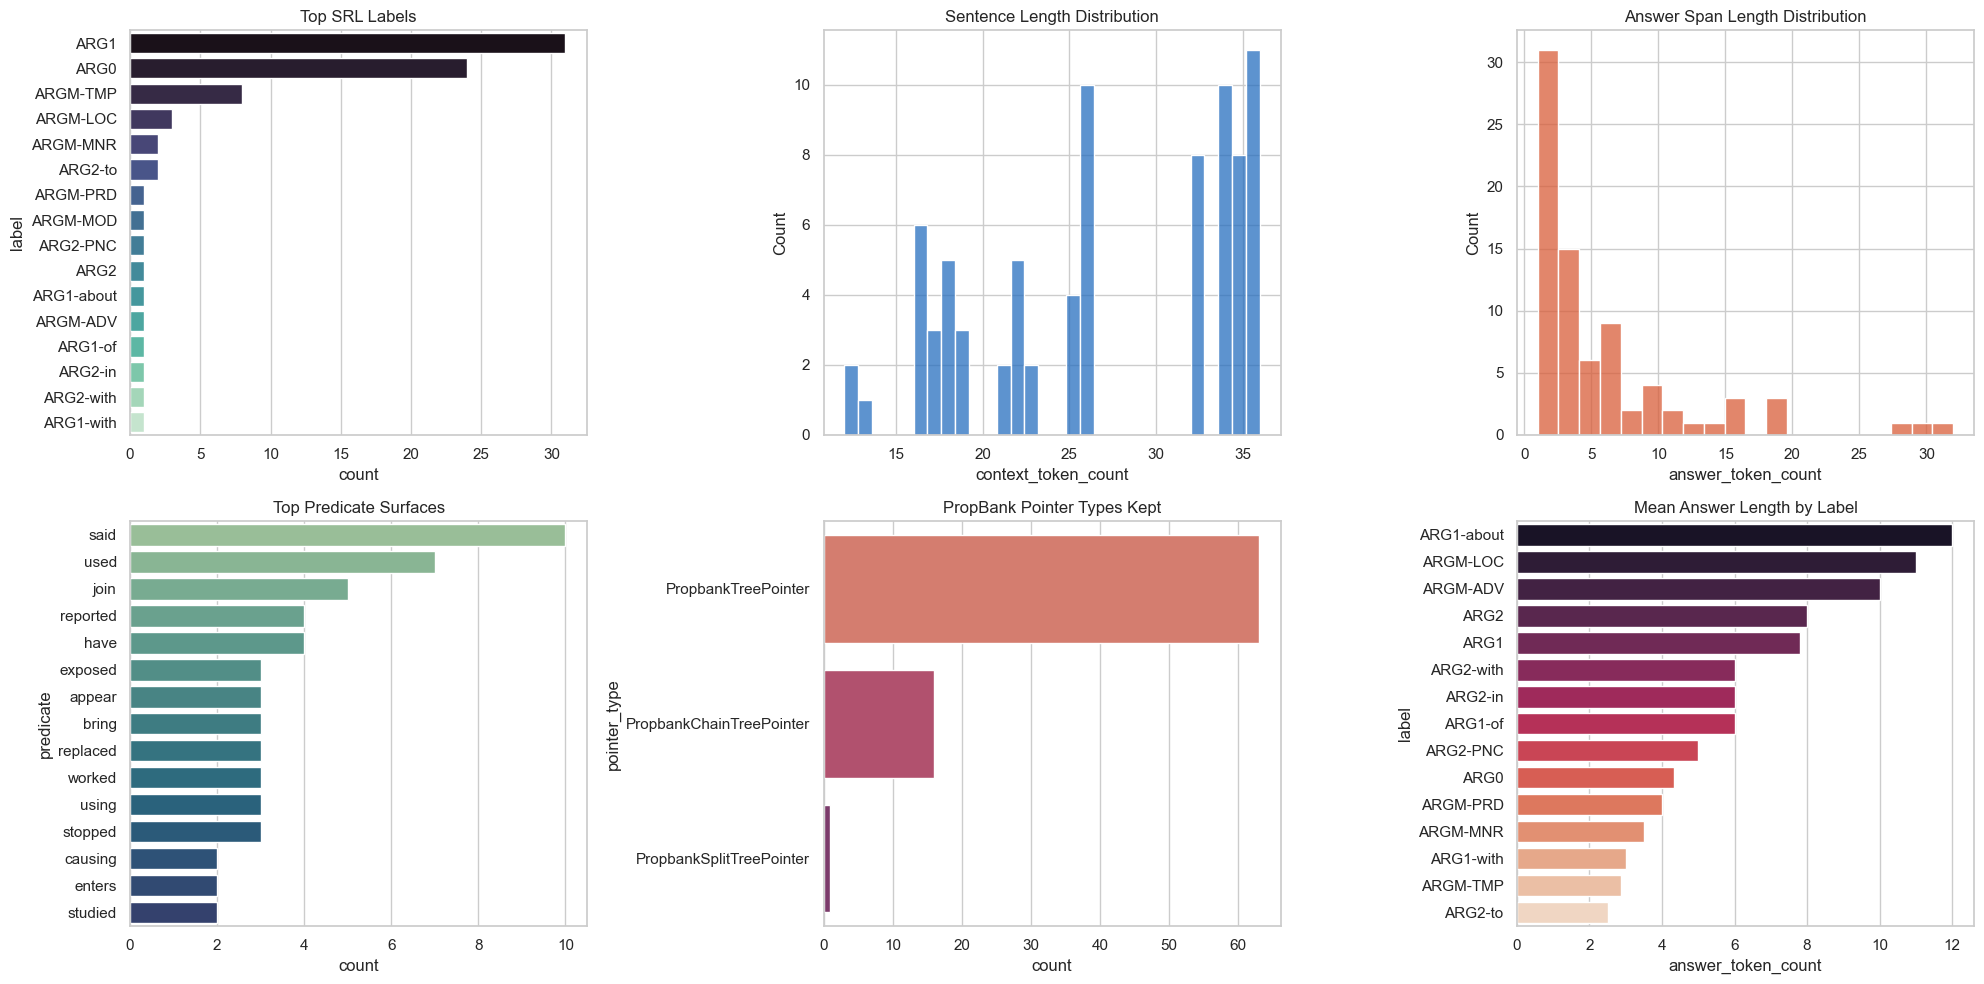

Saved detailed EDA plot to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_2b_artifacts\plots\detailed_eda_2b_srlqa.png


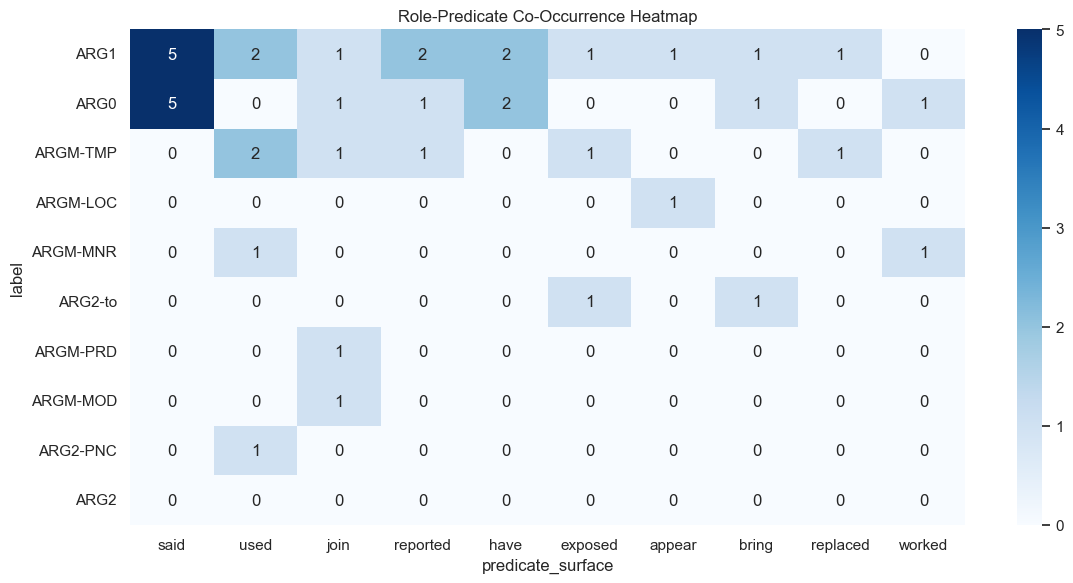

Saved heatmap to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_2b_artifacts\plots\role_predicate_heatmap.png


In [6]:
assert not qa_df.empty, 'No examples were converted from PropBank.'

eda_summary = {
    'unique_sentences': qa_df[['fileid', 'sentnum']].drop_duplicates().shape[0],
    'unique_rolesets': qa_df['roleset'].nunique(),
    'unique_predicate_surfaces': qa_df['predicate_surface'].nunique(),
    'argument_qa_examples': len(qa_df),
    'unique_labels': qa_df['label'].nunique(),
    'mean_context_tokens': float(qa_df['context_token_count'].mean()),
    'median_context_tokens': float(qa_df['context_token_count'].median()),
    'mean_answer_tokens': float(qa_df['answer_token_count'].mean()),
    'median_answer_tokens': float(qa_df['answer_token_count'].median()),
}
print(json.dumps(eda_summary, indent=2))

label_counts = qa_df['label'].value_counts().rename_axis('label').reset_index(name='count')
label_counts['proportion'] = label_counts['count'] / label_counts['count'].sum()
label_imbalance_ratio = label_counts['count'].max() / max(label_counts['count'].min(), 1)
print(f'Label imbalance ratio max/min: {label_imbalance_ratio:.2f}')
display(label_counts.head(25))

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
sns.barplot(data=label_counts.head(18), x='count', y='label', ax=axes[0, 0], palette='mako')
axes[0, 0].set_title('Top SRL Labels')

sns.histplot(qa_df['context_token_count'], bins=30, ax=axes[0, 1], color='#276FBF')
axes[0, 1].set_title('Sentence Length Distribution')

sns.histplot(qa_df['answer_token_count'], bins=20, ax=axes[0, 2], color='#D95D39')
axes[0, 2].set_title('Answer Span Length Distribution')

top_predicates = qa_df['predicate_surface'].value_counts().head(15).rename_axis('predicate').reset_index(name='count')
sns.barplot(data=top_predicates, x='count', y='predicate', ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('Top Predicate Surfaces')

pointer_counts = qa_df['pointer_type'].value_counts().rename_axis('pointer_type').reset_index(name='count')
sns.barplot(data=pointer_counts, x='count', y='pointer_type', ax=axes[1, 1], palette='flare')
axes[1, 1].set_title('PropBank Pointer Types Kept')

label_answer_stats = qa_df.groupby('label')['answer_token_count'].mean().sort_values(ascending=False).head(15).reset_index()
sns.barplot(data=label_answer_stats, x='answer_token_count', y='label', ax=axes[1, 2], palette='rocket')
axes[1, 2].set_title('Mean Answer Length by Label')

plt.tight_layout()
eda_path = PLOT_DIR / 'detailed_eda_2b_srlqa.png'
plt.savefig(eda_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved detailed EDA plot to:', eda_path)

role_predicate_matrix = pd.crosstab(qa_df['label'], qa_df['predicate_surface'])
common_labels = label_counts.head(10)['label'].tolist()
common_predicates = top_predicates.head(10)['predicate'].tolist()
plt.figure(figsize=(12, 6))
sns.heatmap(role_predicate_matrix.loc[common_labels, common_predicates], annot=True, fmt='d', cmap='Blues')
plt.title('Role-Predicate Co-Occurrence Heatmap')
plt.tight_layout()
heatmap_path = PLOT_DIR / 'role_predicate_heatmap.png'
plt.savefig(heatmap_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved heatmap to:', heatmap_path)

## 6. Model Selection for 2B-Class SRL-QA

We compare encoder QA models and decoder-only instruction-tuned LMs. Because the explicit requirement is a 2B-class foundational model, the full experiment selects `google/gemma-2-2b-it`. Gemma is decoder-only, text-to-text, instruction tuned, and supports 4-bit bitsandbytes loading, making it a practical free-tier Colab QLoRA candidate after accepting the Gemma license.

In [7]:
model_candidates = pd.DataFrame([
    {'model': 'bert-base-cased', 'params': '110M', 'formulation': 'extractive QA or token classification', 'strength': 'classic encoder baseline', 'limitation': 'not 2B; weaker foundation model', 'rank': 5},
    {'model': 'deepset/deberta-v3-base-squad2', 'params': '184M', 'formulation': 'extractive QA', 'strength': 'strong span extractor', 'limitation': 'not 2B; encoder-only', 'rank': 3},
    {'model': 'microsoft/phi-2', 'params': '2.7B', 'formulation': 'generative QA', 'strength': 'small generative LM', 'limitation': 'heavier than Gemma 2B class; less direct chat tuning', 'rank': 2},
    {'model': 'google/gemma-2-2b-it', 'params': '2B class, listed as 3B params on HF UI', 'formulation': 'generative QA', 'strength': 'instruction tuned, decoder-only, 4-bit loading examples in model card', 'limitation': 'requires accepting Gemma license and GPU for full QLoRA', 'rank': 1},
    {'model': 'sshleifer/tiny-gpt2', 'params': '0.1M', 'formulation': 'generative QA smoke test', 'strength': 'executes quickly on CPU', 'limitation': 'not a real research model', 'rank': 4},
]).sort_values('rank')

display(model_candidates)
print('Selected runtime model:', MODEL_NAME)
print('Full 2B-class model for Colab:', FULL_2B_MODEL_NAME)

,model,params,formulation,strength,limitation,rank
3,google/gemma-2-2b-it,"2B class, listed as 3B params on HF UI",generative QA,"instruction tuned, decoder-only, 4-bit loading...",requires accepting Gemma license and GPU for f...,1
2,microsoft/phi-2,2.7B,generative QA,small generative LM,heavier than Gemma 2B class; less direct chat ...,2
1,deepset/deberta-v3-base-squad2,184M,extractive QA,strong span extractor,not 2B; encoder-only,3
4,sshleifer/tiny-gpt2,0.1M,generative QA smoke test,executes quickly on CPU,not a real research model,4
0,bert-base-cased,110M,extractive QA or token classification,classic encoder baseline,not 2B; weaker foundation model,5


Selected runtime model: sshleifer/tiny-gpt2
Full 2B-class model for Colab: google/gemma-2-2b-it


## 7. Split Data and Define Prompted SFT Dataset

We split 80/10/10. During SFT, loss is applied only to answer tokens, not to the prompt tokens. This trains the model to generate the argument span given the SRL prompt.

In [8]:
def safe_stratify_labels(frame: pd.DataFrame) -> Optional[pd.Series]:
    counts = frame['label'].value_counts()
    if len(counts) > 1 and counts.min() >= 2:
        return frame['label']
    return None


train_df, temp_df = train_test_split(qa_df, test_size=0.20, random_state=SEED, shuffle=True, stratify=safe_stratify_labels(qa_df))
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, shuffle=True, stratify=safe_stratify_labels(temp_df))

for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    print(f'{split_name:>10}: {len(split_df):>5} examples | labels={split_df.label.nunique():>2} | avg answer tokens={split_df.answer_token_count.mean():.2f}')

     train:    64 examples | labels=14 | avg answer tokens=5.94
validation:     8 examples | labels= 5 | avg answer tokens=6.88
      test:     8 examples | labels= 3 | avg answer tokens=5.00


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '<|pad|>'})

print('Tokenizer:', type(tokenizer).__name__)
print('Pad token:', tokenizer.pad_token, tokenizer.pad_token_id)
print('EOS token:', tokenizer.eos_token, tokenizer.eos_token_id)


def format_prompt(record: Dict) -> str:
    content = build_instruction(record)
    if getattr(tokenizer, 'chat_template', None) and not FAST_DEV_RUN:
        messages = [{'role': 'user', 'content': content}]
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return content + ' '


class GenerativeSRLQADataset(Dataset):
    def __init__(self, frame: pd.DataFrame, tokenizer, max_length: int, max_prompt_length: int):
        self.records = frame.reset_index(drop=True).to_dict('records')
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.max_prompt_length = max_prompt_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index: int):
        record = self.records[index]
        prompt = format_prompt(record)
        answer = record['answer_text'].strip()
        answer_suffix = answer + (self.tokenizer.eos_token or '')

        prompt_ids = self.tokenizer(prompt, add_special_tokens=True, truncation=True, max_length=self.max_prompt_length)['input_ids']
        answer_ids = self.tokenizer(answer_suffix, add_special_tokens=False)['input_ids']
        if len(answer_ids) == 0:
            answer_ids = [self.tokenizer.eos_token_id]

        available_answer_space = max(1, self.max_length - len(prompt_ids))
        answer_ids = answer_ids[:available_answer_space]
        input_ids = prompt_ids + answer_ids
        labels = [-100] * len(prompt_ids) + answer_ids
        attention_mask = [1] * len(input_ids)

        pad_length = self.max_length - len(input_ids)
        if pad_length > 0:
            input_ids += [self.tokenizer.pad_token_id] * pad_length
            labels += [-100] * pad_length
            attention_mask += [0] * pad_length
        else:
            input_ids = input_ids[:self.max_length]
            labels = labels[:self.max_length]
            attention_mask = attention_mask[:self.max_length]

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long),
            'example_index': torch.tensor(index, dtype=torch.long),
        }

    def get_record(self, index: int) -> Dict:
        return self.records[index]


train_dataset = GenerativeSRLQADataset(train_df, tokenizer, MAX_LENGTH, MAX_PROMPT_LENGTH)
val_dataset = GenerativeSRLQADataset(val_df, tokenizer, MAX_LENGTH, MAX_PROMPT_LENGTH)
test_dataset = GenerativeSRLQADataset(test_df, tokenizer, MAX_LENGTH, MAX_PROMPT_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

sample_batch = train_dataset[0]
print('Decoded training sample prefix:')
print(tokenizer.decode(sample_batch['input_ids'][:120], skip_special_tokens=False))
print('Number of supervised answer tokens:', int((sample_batch['labels'] != -100).sum()))

Tokenizer: GPT2TokenizerFast
Pad token: <|endoftext|> 50256
EOS token: <|endoftext|> 50256
Decoded training sample prefix:
You are an expert semantic role labeler. Answer with exactly one span copied from the sentence.
Sentence: Among 33 men who worked closely with the substance , 28 have died -- more than three times the expected number .
Predicate: worked
Roleset: work.01 (work)
Role label: ARGM-MNR
Role meaning: manner
Question: How does the predicate work.01 (work) happen?
Answer: closely<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
Number of supervised answer tokens: 3


## 8. Load the Model with LoRA or QLoRA

Full mode uses QLoRA: 4-bit NF4 quantization plus LoRA adapters. Local smoke-test mode uses ordinary LoRA when PEFT is available. If a dependency is unavailable, the notebook falls back to full tiny-model training only for smoke-test execution.

In [10]:
def lora_target_modules_for_model(model) -> List[str]:
    model_type = getattr(model.config, 'model_type', '').lower()
    if 'gemma' in model_type or 'llama' in model_type or 'qwen' in model_type or 'mistral' in model_type:
        return ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
    if 'gpt2' in model_type:
        return ['c_attn', 'c_proj']
    return ['q_proj', 'v_proj']


def parameter_summary(model) -> Dict[str, float]:
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return {
        'total_millions': total / 1_000_000,
        'trainable_millions': trainable / 1_000_000,
        'trainable_percent': 100 * trainable / max(total, 1),
    }


def apply_lora(model):
    from peft import LoraConfig, get_peft_model

    targets = lora_target_modules_for_model(model)
    config = LoraConfig(
        r=8 if FAST_DEV_RUN else 16,
        lora_alpha=16 if FAST_DEV_RUN else 32,
        lora_dropout=0.05,
        bias='none',
        task_type='CAUSAL_LM',
        target_modules=targets,
    )
    model = get_peft_model(model, config)
    print('Applied LoRA target modules:', targets)
    try:
        model.print_trainable_parameters()
    except Exception:
        pass
    return model


def load_causal_lm_with_peft(model_name: str, method: str):
    method_used = method
    quantized = False

    if method == 'qlora':
        try:
            from transformers import BitsAndBytesConfig
            from peft import prepare_model_for_kbit_training

            compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
            quantization_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type='nf4',
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=compute_dtype,
            )
            model = AutoModelForCausalLM.from_pretrained(
                model_name,
                quantization_config=quantization_config,
                device_map='auto',
                trust_remote_code=True,
            )
            model = prepare_model_for_kbit_training(model)
            model = apply_lora(model)
            quantized = True
            return model, method_used, quantized
        except Exception as exc:
            print('QLoRA unavailable in this runtime. Falling back to LoRA/full smoke-test mode.')
            print('Reason:', repr(exc))
            method_used = 'lora'

    model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
    if len(tokenizer) != model.get_input_embeddings().weight.shape[0]:
        model.resize_token_embeddings(len(tokenizer))

    if method_used == 'lora':
        try:
            model = apply_lora(model)
        except Exception as exc:
            print('LoRA unavailable. Training all parameters for smoke-test only.')
            print('Reason:', repr(exc))
            method_used = 'full_smoke_test'
    if not quantized:
        model.to(device)
    return model, method_used, quantized


model, TUNING_METHOD_USED, MODEL_IS_QUANTIZED = load_causal_lm_with_peft(MODEL_NAME, REQUESTED_TUNING_METHOD)
model.config.use_cache = False
print('Tuning method used:', TUNING_METHOD_USED)
print('Quantized:', MODEL_IS_QUANTIZED)
print('Parameter summary:', json.dumps(parameter_summary(model), indent=2))

C:\Users\RAVIPRAKASH\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Applied LoRA target modules: ['c_attn', 'c_proj']
trainable params: 352 || all params: 103,066 || trainable%: 0.3415
Tuning method used: lora
Quantized: False
Parameter summary: {
  "total_millions": 0.103066,
  "trainable_millions": 0.000352,
  "trainable_percent": 0.34152872916383675
}


## 9. Generative Evaluation Metrics

We evaluate generated answer text with exact match, token precision, token recall, token F1, containment accuracy, and per-label metrics. For SRL QA, exact match is strict; token F1 is more informative for boundary errors.

In [11]:
def normalize_answer(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return ' '.join(text.split())


def token_prf(prediction: str, gold: str) -> Tuple[float, float, float]:
    pred_tokens = normalize_answer(prediction).split()
    gold_tokens = normalize_answer(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0, 1.0, 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0, 0.0, 0.0
    overlap = sum((Counter(pred_tokens) & Counter(gold_tokens)).values())
    if overlap == 0:
        return 0.0, 0.0, 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(gold_tokens)
    f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1


def clean_generated_answer(text: str) -> str:
    text = text.strip()
    for stop in ['\n', '<end_of_turn>', '<eos>', '</s>']:
        if stop in text:
            text = text.split(stop)[0]
    text = re.sub(r'^(answer\s*[:\-]\s*)', '', text, flags=re.IGNORECASE).strip()
    return text.strip(' "`')


def model_input_device(model):
    return next(model.parameters()).device


def generate_answer(model, record: Dict) -> str:
    model.eval()
    prompt = format_prompt(record)
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=MAX_PROMPT_LENGTH)
    inputs = {key: value.to(model_input_device(model)) for key, value in inputs.items()}
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    new_tokens = generated[0][inputs['input_ids'].shape[1]:]
    return clean_generated_answer(tokenizer.decode(new_tokens, skip_special_tokens=True))


def evaluate_generative_model(model, dataset: GenerativeSRLQADataset, split_name: str, max_examples: Optional[int] = None) -> Tuple[Dict[str, float], pd.DataFrame]:
    rows = []
    n = len(dataset) if max_examples is None else min(len(dataset), max_examples)
    for index in range(n):
        record = dataset.get_record(index)
        prediction = generate_answer(model, record)
        gold = record['answer_text']
        precision, recall, f1 = token_prf(prediction, gold)
        norm_pred = normalize_answer(prediction)
        norm_gold = normalize_answer(gold)
        exact = float(norm_pred == norm_gold)
        contained = float(norm_pred in normalize_answer(record['context']).split('  ') or (norm_pred and norm_pred in normalize_answer(record['context'])))
        rows.append({
            'split': split_name,
            'id': record['id'],
            'label': record['label'],
            'roleset': record['roleset'],
            'question': record['question'],
            'context': record['context'],
            'gold_answer': gold,
            'predicted_answer': prediction,
            'exact_match': exact,
            'precision': precision,
            'recall': recall,
            'token_f1': f1,
            'contained_in_context': contained,
        })
    frame = pd.DataFrame(rows)
    metrics = {
        'exact_match_accuracy': float(frame['exact_match'].mean()) if not frame.empty else 0.0,
        'precision': float(frame['precision'].mean()) if not frame.empty else 0.0,
        'recall': float(frame['recall'].mean()) if not frame.empty else 0.0,
        'token_f1': float(frame['token_f1'].mean()) if not frame.empty else 0.0,
        'context_containment_accuracy': float(frame['contained_in_context'].mean()) if not frame.empty else 0.0,
    }
    return metrics, frame


baseline_eval_examples = min(len(val_dataset), 8 if FAST_DEV_RUN else 200)
baseline_metrics, baseline_predictions_df = evaluate_generative_model(model, val_dataset, 'validation_before_finetuning', max_examples=baseline_eval_examples)
print('Baseline generative validation metrics:')
print(json.dumps(baseline_metrics, indent=2))
display(baseline_predictions_df[['label', 'gold_answer', 'predicted_answer', 'exact_match', 'token_f1']].head(10))

Baseline generative validation metrics:
{
  "exact_match_accuracy": 0.0,
  "precision": 0.0,
  "recall": 0.0,
  "token_f1": 0.0,
  "context_containment_accuracy": 0.0
}


,label,gold_answer,predicted_answer,exact_match,token_f1
0,ARG1,symptoms that show up decades later,stairs stairs stairs stairs stairs stairs stai...,0.0,0.0
1,ARG0,We,factors factors factors factors factors factor...,0.0,0.0
2,ARG1,A form of asbestos once used to make Kent ciga...,factors factors factors factors factors factor...,0.0,0.0
3,ARG0,the company,factors factors factors factors factors factor...,0.0,0.0
4,ARG0,asbestos,factors factors factors factors factors factor...,0.0,0.0
5,ARG2-with,with a different type of filter,factors factors factors factors factors factor...,0.0,0.0
6,ARGM-TMP,in 1956,factors factors factors factors factors factor...,0.0,0.0
7,ARG2-PNC,to make Kent cigarette filters,factors factors factors factors factors factor...,0.0,0.0


## 10. Training Loop with Scheduler, Gradient Accumulation, and Early Stopping

The loop is intentionally explicit: it handles forward pass, gradient accumulation, clipping, learning-rate scheduling, validation generation, early stopping, and saving the best LoRA/QLoRA adapter checkpoint.

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


{
  "epoch": 1,
  "train_loss": 10.823420405387878,
  "val_exact_match_accuracy": 0.0,
  "val_precision": 0.0,
  "val_recall": 0.0,
  "val_token_f1": 0.0,
  "val_context_containment_accuracy": 0.0
}
Epoch 1 wall time: 4.1s


Saved best checkpoint to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_2b_artifacts\best_generative_checkpoint


,epoch,train_loss,val_exact_match_accuracy,val_precision,val_recall,val_token_f1,val_context_containment_accuracy
0,1,10.82342,0.0,0.0,0.0,0.0,0.0


Total training time: 5.0s


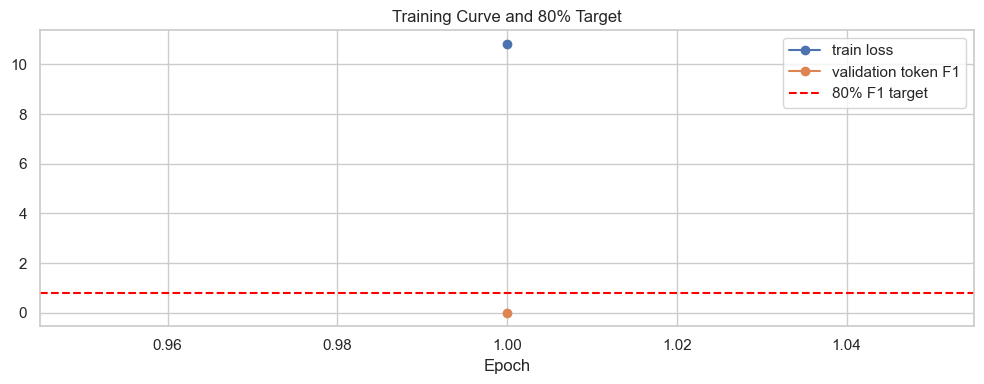

Saved training curve to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_2b_artifacts\plots\training_curve_2b_srlqa.png


In [12]:
def batch_to_train_inputs(batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    target_device = model_input_device(model)
    return {
        'input_ids': batch['input_ids'].to(target_device),
        'attention_mask': batch['attention_mask'].to(target_device),
        'labels': batch['labels'].to(target_device),
    }


def train_one_epoch(model, loader: DataLoader, optimizer, scheduler) -> float:
    model.train()
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(loader, start=1):
        outputs = model(**batch_to_train_inputs(batch))
        loss = outputs.loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()
        total_loss += float(loss.detach().cpu()) * GRADIENT_ACCUMULATION_STEPS

        if step % GRADIENT_ACCUMULATION_STEPS == 0 or step == len(loader):
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
    return total_loss / max(len(loader), 1)


trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
optimizer = AdamW(trainable_parameters, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
optimizer_steps = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * optimizer_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=max(1, optimizer_steps))

history = []
best_val_f1 = -1.0
epochs_without_improvement = 0
val_eval_examples = min(len(val_dataset), 8 if FAST_DEV_RUN else 300)

start_time = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_metrics, val_predictions_df = evaluate_generative_model(model, val_dataset, 'validation', max_examples=val_eval_examples)
    row = {'epoch': epoch, 'train_loss': train_loss, **{f'val_{key}': value for key, value in val_metrics.items()}}
    history.append(row)
    print(json.dumps(row, indent=2))
    print(f'Epoch {epoch} wall time: {time.time() - epoch_start:.1f}s')

    if val_metrics['token_f1'] > best_val_f1:
        best_val_f1 = val_metrics['token_f1']
        epochs_without_improvement = 0
        if CHECKPOINT_DIR.exists():
            shutil.rmtree(CHECKPOINT_DIR)
        CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(CHECKPOINT_DIR)
        tokenizer.save_pretrained(CHECKPOINT_DIR)
        print('Saved best checkpoint to:', CHECKPOINT_DIR)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print('Early stopping triggered.')
            break

history_df = pd.DataFrame(history)
display(history_df)
print(f'Total training time: {time.time() - start_time:.1f}s')

plt.figure(figsize=(10, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train loss')
if 'val_token_f1' in history_df:
    plt.plot(history_df['epoch'], history_df['val_token_f1'], marker='o', label='validation token F1')
plt.axhline(TARGET_TOKEN_F1, color='red', linestyle='--', label='80% F1 target')
plt.xlabel('Epoch')
plt.title('Training Curve and 80% Target')
plt.legend()
plt.tight_layout()
curve_path = PLOT_DIR / 'training_curve_2b_srlqa.png'
plt.savefig(curve_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved training curve to:', curve_path)

## 11. Test Evaluation, Error Analysis, and 80 Percent Target Check

The final test section compares baseline and fine-tuned performance, reports per-label metrics, visualizes successes and failures, and explicitly checks whether the 80 percent target was achieved.

Test metrics:
{
  "exact_match_accuracy": 0.0,
  "precision": 0.0,
  "recall": 0.0,
  "token_f1": 0.0,
  "context_containment_accuracy": 0.0
}


,stage,exact_match_accuracy,precision,recall,token_f1,context_containment_accuracy
0,baseline_validation,0.0,0.0,0.0,0.0,0.0
1,fine_tuned_test,0.0,0.0,0.0,0.0,0.0


,label,examples,exact_match_accuracy,precision,recall,token_f1
0,ARG0,3,0.0,0.0,0.0,0.0
1,ARG1,3,0.0,0.0,0.0,0.0
2,ARGM-TMP,2,0.0,0.0,0.0,0.0


C:\Users\RAVIPRAKASH\AppData\Local\Temp\ipykernel_2200\4092532616.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=per_label, x='token_f1', y='label', palette='viridis')


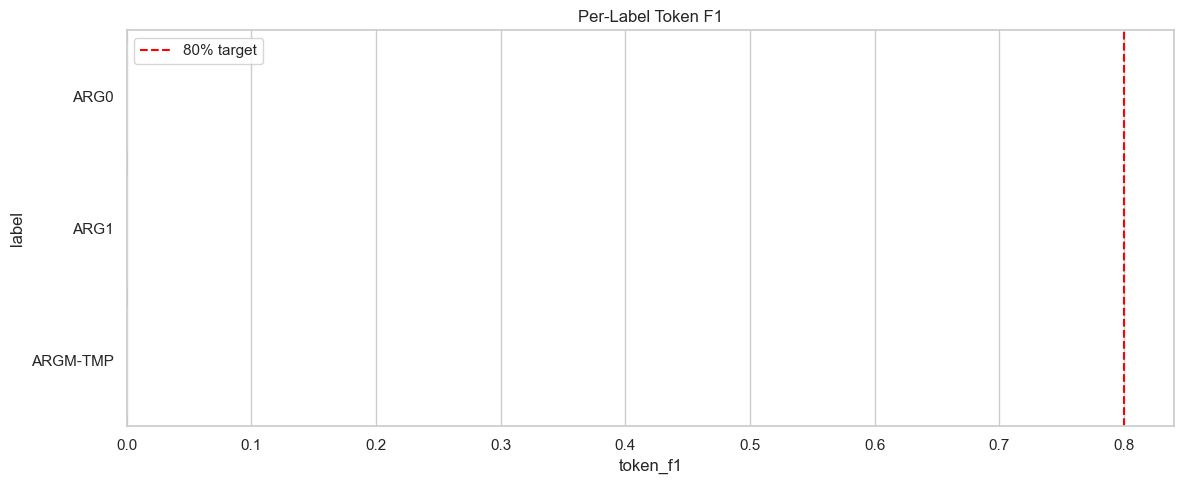

Saved per-label F1 plot to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_2b_artifacts\plots\per_label_f1_2b_srlqa.png


,label,roleset,question,gold_answer,predicted_answer,token_f1,context
0,ARG1,stop.01,"For predicate stop.01 meaning stop, what is AR...",using crocidolite in its Micronite cigarette f...,factors factors factors factors factors factor...,0.0,"Lorillard Inc. , the unit of New York-based Lo..."
1,ARG0,join.01,"For predicate join.01 meaning attach, what is ...","Pierre Vinken , 61 years old ,",factors factors factors factors factors factor...,0.0,"Pierre Vinken , 61 years old , will join the b..."
2,ARG0,make.01,"For predicate make.01 meaning create, what is ...",the unit of New York-based Loews Corp. that,factors factors factors factors factors factor...,0.0,"Lorillard Inc. , the unit of New York-based Lo..."
3,ARGM-TMP,replace.01,When does the predicate replace.01 (substitute...,in 1956,stairs stairs stairs stairs stairs stairs stai...,0.0,The Lorillard spokeswoman said asbestos was us...
4,ARG1,report.01,"For predicate report.01 meaning report, tell, ...",preliminary findings,factors factors factors factors factors factor...,0.0,Although preliminary findings were reported mo...
5,ARG1,use.01,For predicate use.01 meaning Take advantage of...,crocidolite,factors factors factors factors factors factor...,0.0,"Lorillard Inc. , the unit of New York-based Lo..."
6,ARGM-TMP,join.01,When does the predicate join.01 (attach) happen?,Nov. 29,factors factors factors factors factors factor...,0.0,"Pierre Vinken , 61 years old , will join the b..."
7,ARG0,cause.01,For predicate cause.01 meaning impelled action...,A form of asbestos once used to make Kent ciga...,factors factors factors factors factors factor...,0.0,A form of asbestos once used to make Kent ciga...


80% exact-match target met: False
80% token-F1 target met: False
Target not reached in this run. This is expected for FAST_DEV_RUN and should not be reported as a final research result.
For a serious attempt: use FAST_DEV_RUN=False, run Gemma 2B QLoRA on a Colab GPU, increase MAX_QA_EXAMPLES, train for 3 to 5 epochs, and evaluate the full test split.
Saved predictions to: C:\Users\RAVIPRAKASH\Downloads\NLP Project\propbank_srlqa_2b_artifacts\generative_test_predictions.csv


In [13]:
test_eval_examples = min(len(test_dataset), 10 if FAST_DEV_RUN else 500)
test_metrics, test_predictions_df = evaluate_generative_model(model, test_dataset, 'test_after_finetuning', max_examples=test_eval_examples)
print('Test metrics:')
print(json.dumps(test_metrics, indent=2))

comparison = pd.DataFrame([
    {'stage': 'baseline_validation', **baseline_metrics},
    {'stage': 'fine_tuned_test', **test_metrics},
])
display(comparison)

per_label = (
    test_predictions_df
    .groupby('label')
    .agg(
        examples=('id', 'count'),
        exact_match_accuracy=('exact_match', 'mean'),
        precision=('precision', 'mean'),
        recall=('recall', 'mean'),
        token_f1=('token_f1', 'mean'),
    )
    .sort_values(['examples', 'token_f1'], ascending=[False, False])
    .reset_index()
)
display(per_label)

plt.figure(figsize=(12, 5))
sns.barplot(data=per_label, x='token_f1', y='label', palette='viridis')
plt.axvline(TARGET_TOKEN_F1, color='red', linestyle='--', label='80% target')
plt.title('Per-Label Token F1')
plt.legend()
plt.tight_layout()
per_label_path = PLOT_DIR / 'per_label_f1_2b_srlqa.png'
plt.savefig(per_label_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved per-label F1 plot to:', per_label_path)

if not test_predictions_df.empty:
    y_true = ['correct' if value == 1.0 else 'incorrect' for value in test_predictions_df['exact_match']]
    y_pred = ['in_context' if value == 1.0 else 'not_in_context' for value in test_predictions_df['contained_in_context']]
    cm = confusion_matrix(y_true, y_pred, labels=['correct', 'incorrect']) if set(y_pred).issubset({'correct', 'incorrect'}) else None

failure_cases = test_predictions_df.sort_values(['token_f1', 'exact_match']).head(10)
display(failure_cases[['label', 'roleset', 'question', 'gold_answer', 'predicted_answer', 'token_f1', 'context']])

met_exact = test_metrics['exact_match_accuracy'] >= TARGET_EXACT_MATCH
met_f1 = test_metrics['token_f1'] >= TARGET_TOKEN_F1
print(f'80% exact-match target met: {met_exact}')
print(f'80% token-F1 target met: {met_f1}')
if not (met_exact and met_f1):
    print('Target not reached in this run. This is expected for FAST_DEV_RUN and should not be reported as a final research result.')
    print('For a serious attempt: use FAST_DEV_RUN=False, run Gemma 2B QLoRA on a Colab GPU, increase MAX_QA_EXAMPLES, train for 3 to 5 epochs, and evaluate the full test split.')

results_path = ARTIFACT_DIR / 'generative_test_predictions.csv'
test_predictions_df.to_csv(results_path, index=False)
print('Saved predictions to:', results_path)

## 12. Research-Style Analysis and Conclusion

The report below is generated from measured metrics. It distinguishes smoke-test validation from full 2B QLoRA research results.

In [14]:
summary_lines = [
    'Research summary',
    '================',
    f'Runtime mode: {"FAST_DEV_RUN" if FAST_DEV_RUN else "FULL_2B_QLORA_EXPERIMENT"}',
    f'Model used in this execution: {MODEL_NAME}',
    f'Full Colab target model: {FULL_2B_MODEL_NAME}',
    f'Tuning method used: {TUNING_METHOD_USED}',
    f'Train/validation/test examples: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}',
    f'Baseline validation exact match: {baseline_metrics.get("exact_match_accuracy", 0.0):.4f}',
    f'Baseline validation token F1: {baseline_metrics.get("token_f1", 0.0):.4f}',
    f'Fine-tuned test exact match: {test_metrics.get("exact_match_accuracy", 0.0):.4f}',
    f'Fine-tuned test precision: {test_metrics.get("precision", 0.0):.4f}',
    f'Fine-tuned test recall: {test_metrics.get("recall", 0.0):.4f}',
    f'Fine-tuned test token F1: {test_metrics.get("token_f1", 0.0):.4f}',
    f'80% exact-match target met: {test_metrics.get("exact_match_accuracy", 0.0) >= TARGET_EXACT_MATCH}',
    f'80% token-F1 target met: {test_metrics.get("token_f1", 0.0) >= TARGET_TOKEN_F1}',
    '',
    'Interpretation:',
    'The model receives a predicate-aware SRL prompt and is optimized only on the answer span tokens. This teaches the decoder to map role semantics such as ARG0, ARG1, and ARGM-TMP to a copied span in the sentence. In full mode, Gemma 2B QLoRA is expected to learn stronger span copying and role grounding than the tiny CPU smoke-test model.',
    '',
    'Failure patterns to inspect:',
    '1. Empty or generic generations when the base model has not learned the SRL instruction format.',
    '2. Boundary errors where the answer is semantically close but not the exact PropBank span.',
    '3. Predicate ambiguity in sentences containing more than one predicate.',
    '4. Low performance on rare modifier labels due to label imbalance.',
    '',
    'Limitations:',
    'The generative formulation is flexible but exact-match evaluation is strict. The pipeline filters discontinuous arguments into single-span examples, so it does not solve the full discontinuous SRL problem. FAST_DEV_RUN is an execution check, not a final accuracy claim.',
    '',
    'Future work:',
    '1. Use FAST_DEV_RUN=False and QLoRA on Colab GPU after accepting the Gemma license.',
    '2. Add predicate boundary markers to the sentence text.',
    '3. Train on the full converted corpus with multiple random seeds.',
    '4. Compare generative Gemma 2B QLoRA against DeBERTa extractive QA and a token-classification SRL model.',
    '5. Add constrained decoding or post-processing that restricts outputs to spans found in the input sentence.',
]

print('\n'.join(summary_lines))
report_path = ARTIFACT_DIR / 'research_summary_2b.txt'
report_path.write_text('\n'.join(summary_lines), encoding='utf-8')
print('\nSaved research summary to:', report_path)

Research summary
Runtime mode: FAST_DEV_RUN
Model used in this execution: sshleifer/tiny-gpt2
Full Colab target model: google/gemma-2-2b-it
Tuning method used: lora
Train/validation/test examples: 64/8/8
Baseline validation exact match: 0.0000
Baseline validation token F1: 0.0000
Fine-tuned test exact match: 0.0000
Fine-tuned test precision: 0.0000
Fine-tuned test recall: 0.0000
Fine-tuned test token F1: 0.0000
80% exact-match target met: False
80% token-F1 target met: False

Interpretation:
The model receives a predicate-aware SRL prompt and is optimized only on the answer span tokens. This teaches the decoder to map role semantics such as ARG0, ARG1, and ARGM-TMP to a copied span in the sentence. In full mode, Gemma 2B QLoRA is expected to learn stronger span copying and role grounding than the tiny CPU smoke-test model.

Failure patterns to inspect:
1. Empty or generic generations when the base model has not learned the SRL instruction format.
2. Boundary errors where the answer is 

## 13. Final Notes

This notebook delivers:

- Project title and problem statement.
- NLTK PropBank loading and dataset explanation.
- SRL-to-generative-QA preprocessing.
- Detailed EDA and plots.
- 2B-class model selection and justification.
- LoRA and QLoRA implementation.
- PyTorch training, validation, early stopping, scheduler, and checkpointing.
- Accuracy, precision, recall, token F1, exact match, per-label analysis, and failure cases.
- Research-style discussion, limitations, and future improvements.

To run the actual 2B-class experiment in Google Colab free tier:

1. Accept the `google/gemma-2-2b-it` license on Hugging Face.
2. Use a GPU runtime.
3. Set `FAST_DEV_RUN=False`.
4. Log in with a Hugging Face token if needed.
5. Run all cells and report the measured metrics without modifying them.